In [1]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, os, json

pd.set_option('display.max_columns', None)

In [2]:
OPTIONS = json.loads(open('info.json', 'r', encoding='utf-8').read()).get('target')
OPTIONS

{'test': 5, 'axis': 'z'}

In [3]:
ORIENT_VARS = ['pitch', 'roll', 'wx', 'wy', 'wz', 'ax', 'ay', 'az']
axis = OPTIONS.get('axis')

target_axis = 'roll' if axis == 'z' else 'pitch'
calib_axis  = ['roll', 'wx', 'az'] if axis == 'z' else ['pitch', 'wz', 'ax']
print(target_axis, calib_axis)

roll ['roll', 'wx', 'az']


# DADOS

In [4]:
df = pd.read_csv('Format/files/output.csv')
df['ref_'+target_axis] = df.target_e.values

for var in calib_axis:
    if var != target_axis:
        df['ref_' + var] =df['target_' + var]

df

,time,target_wz,target_tmp,target_pitch,target_e,target_ay,target_ax,target_wx,target_wy,target_az,target_roll,target_yaw,static,ref_roll,ref_wx,ref_az
0,0.0,-6.92455,53.0,-1.525,-22.176,10.733555,0.194623,-47.92960,-1.16726,-0.614769,18.043,2.936,False,-22.176,-47.92960,-0.614769
1,0.1,-8.13221,52.9,-0.742,-16.704,11.618576,0.294719,-58.13591,-1.05996,-0.532550,12.732,2.725,False,-16.704,-58.13591,-0.532550
2,0.2,-8.42212,53.1,0.119,-10.440,12.899422,0.256924,-67.53252,-1.95110,-2.312996,6.586,2.578,False,-10.440,-67.53252,-2.312996
3,0.3,-9.92099,53.3,1.010,-3.240,12.406766,0.425020,-67.39252,-1.05936,-0.455019,-0.016,2.655,False,-3.240,-67.39252,-0.455019
4,0.4,-9.44709,52.9,1.984,3.744,12.362390,0.271203,-66.62502,-1.97845,-0.208931,-6.779,2.656,False,3.744,-66.62502,-0.208931
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1796,279.5,-0.00493,55.6,1.368,-1.692,9.717615,0.235938,-0.09929,-0.03678,-0.402014,-2.509,5.289,True,-1.692,-0.09929,-0.402014
1797,279.6,0.50338,55.4,1.367,-1.692,9.768983,0.257170,-0.18597,0.40111,-0.404622,-2.506,5.291,True,-1.692,-0.18597,-0.404622
1798,279.7,0.14588,55.6,1.367,-1.692,9.796167,0.266545,0.06592,-0.14609,-0.485586,-2.506,5.289,True,-1.692,0.06592,-0.485586
1799,279.8,0.04660,55.5,1.367,-1.692,9.755871,0.222170,-0.01801,-0.00522,-0.409330,-2.504,5.290,True,-1.692,-0.01801,-0.409330


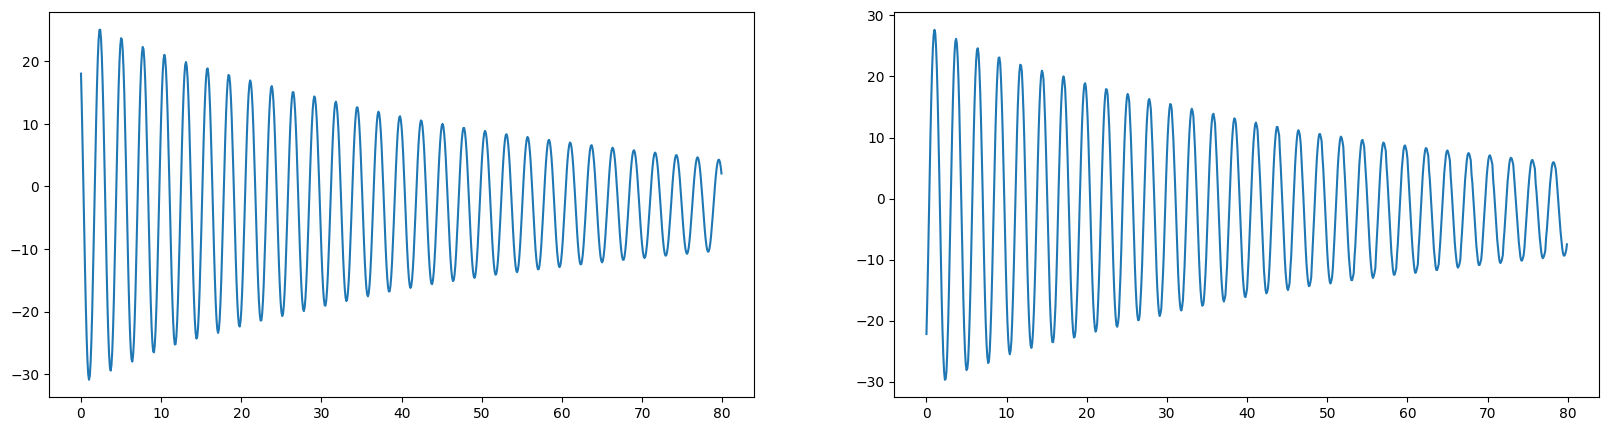

In [5]:
df_static  = df.loc[df.static]
df_dynamic = df.loc[~df.static]
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1); plt.plot(df_dynamic.time, df_dynamic['target_'+target_axis])
plt.subplot(1, 2, 2); plt.plot(df_dynamic.time, df_dynamic['ref_'+target_axis])

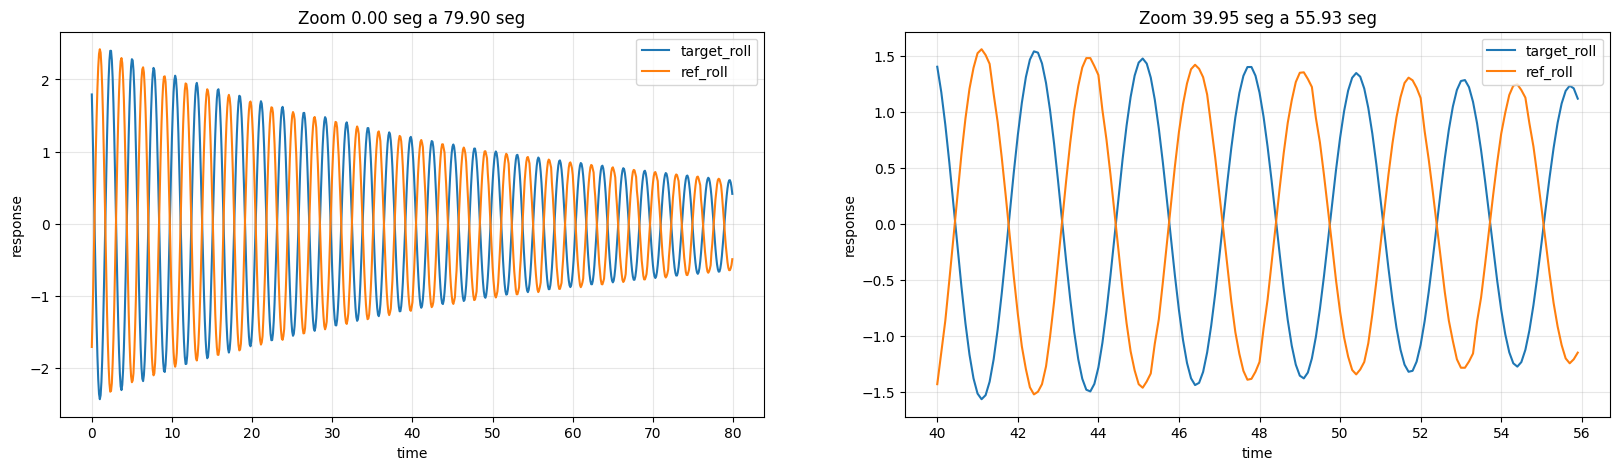

In [6]:
def normalize(array):
    return (array - np.mean(array)) / np.std(array)

def plotViews(df, varname, limits=(0, 1), norm=True):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    values1 = target['target_' + varname] if not norm else normalize(target['target_' + varname])
    values2 = target['ref_' + varname] if not norm else normalize(target['ref_' + varname])

    plt.plot(target.time, values1, label='target_' + varname)
    plt.plot(target.time, values2, label='ref_' + varname)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1); plotViews(df_dynamic, target_axis, limits=(0, 1))
plt.subplot(1, 2, 2); plotViews(df_dynamic, target_axis, limits=(0.5, 0.7))

# DEFASAGEM

In [7]:
class Phaser:
    def __init__(self, target, reference):
        self.target    = target
        self.reference = reference

    def get(self, df):
        import numpy as np
        from scipy.interpolate import interp1d
        from scipy.optimize import minimize
        
        x_norm = (df[self.target] - df[self.target].mean()) / df[self.target].std()
        y_norm = (df[self.reference] - df[self.reference].mean()) / df[self.reference].std()

        correlation = np.correlate(y_norm, x_norm, mode='full')
        lags = np.arange(-len(df) + 1, len(df))
        max_idx = np.argmax(correlation)
        min_idx = np.argmin(correlation)
        if abs(correlation[min_idx]) > abs(correlation[max_idx]):
            discrete_lag = lags[min_idx]
            sign = -1.0
        else:
            discrete_lag = lags[max_idx]
            sign = 1.0
        
        time = df['time'].values
        y_target = df[self.target].values
        y_ref = df[self.reference].values
        
        f_target = interp1d(time, y_target, kind='cubic', bounds_error=False, fill_value=(y_target[0], y_target[-1]))
        
        def objective(params):
            dt, a, b = params
            shifted_time = time - dt
            y_model = a * f_target(shifted_time) + b
            error = y_ref - y_model
            return np.sqrt(np.mean(error**2))

        mean_dt = np.mean(np.diff(time)) if len(time) > 1 else 0.1
        initial_dt = discrete_lag * mean_dt
        
        initial_a = sign * (np.std(y_ref) / np.std(y_target)) if np.std(y_target) != 0 else sign * 1.0
        initial_b = np.mean(y_ref) - initial_a * np.mean(y_target)

        res = minimize(objective, [initial_dt, initial_a, initial_b], method='Nelder-Mead')
        return res.x[0]

    def set(self, df, lag_time):
        if abs(lag_time) < 0.001:
            return df

        from scipy.interpolate import interp1d
        time = df['time'].values
        shifted_time = time - lag_time
        
        df_shifted = df.copy()
        
        target_cols = [c for c in df.columns if c.startswith('target_') and c != self.reference]
        for col in target_cols:
            y_vals = df[col].values
            f_interp = interp1d(time, y_vals, kind='cubic', bounds_error=False, fill_value=(y_vals[0], y_vals[-1]))
            df_shifted[col] = f_interp(shifted_time)
            
        return df_shifted



phaser =  Phaser('target_' + target_axis, 'target_e')
lag    = phaser.get(df_dynamic)

df_dynamic = phaser.set(df_dynamic, lag)
df_static  = phaser.set(df_static, lag)
print('System LAG:', lag, 'samples')

System LAG: -0.007525411254857654 samples


# MODELO DE CALIBRAÇÃO

In [8]:
from scipy.optimize import curve_fit, OptimizeWarning
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=OptimizeWarning)

In [9]:
class LinearFit:
    def __init__(self, df, variables, time_col='time', fuse=False):
        self.df = df
        self.time = np.array(df[time_col])
        self.variables = variables
        self.fuse = fuse
        
        self.X = np.column_stack([df[f'target_{var}'] for var in variables])
        self.Y = np.column_stack([df[f'ref_{var}']    for var in variables])
        
        self.M = np.eye(3)
        self.B = np.zeros(3)

        self.Y_model = np.zeros_like(self.Y)
        self.errors  = np.zeros_like(self.Y)
        self.metrics = {}

    def update(self):
        N = self.X.shape[0]
        
        if not self.fuse: # y = ax + b
            self.M = np.zeros((len(self.variables), len(self.variables)))
            self.B = np.zeros(len(self.variables))
            
            for i in range(len(self.variables)):
                x_single = self.X[:, i].reshape(-1, 1)
                X_aug    = np.hstack((x_single, np.ones((N, 1))))
                w, _, _, _ = np.linalg.lstsq(X_aug, self.Y[:, i], rcond=None)
                
                self.M[i, i] = w[0]  # Scale
                self.B[i]    = w[1]  # Bias
                self.Y_model[:, i] = X_aug @ w
                
        else: # Fusão ativada
            X_aug = np.hstack((self.X, np.ones((N, 1))))
            W, _, _, _ = np.linalg.lstsq(X_aug, self.Y, rcond=None)
            
            self.M = W[:3, :].T
            self.B = W[3, :]
            self.Y_model = X_aug @ W
            
        self.errors = self.Y - self.Y_model
        
        for i, axis in enumerate(self.variables):
            error  = self.errors[:, i]
            y_data = self.Y[:, i]
            
            rmse = np.sqrt(np.mean(error**2))
            mae  = np.mean(np.abs(error))
            max_error = np.max(np.abs(error))
            std_noise = error.std()
            
            ss_res = np.sum(error**2)
            ss_tot = np.sum((y_data - np.mean(y_data))**2)
            r2 = 1.0 if ss_tot == 0 else 1 - (ss_res / ss_tot)
            
            self.metrics[axis] = {
                'r2': r2,
                'mae': mae,
                'rmse': rmse,
                'max_error': max_error,
                'std_noise': std_noise,
                'bias': self.B[i],
                'scale_factor': self.M[i, i]
            }

    def display(self):
        matrix_df = pd.DataFrame(self.M, columns=self.variables, index=[f'{ax}_model' for ax in self.variables])
        matrix_df['bias'] = self.B
        display(matrix_df.style.format("{:.6f}"))

    def plot(self, axis_id, view_limits=None):
        axis_name = self.variables[axis_id]
        t_max     = self.time[-1]
        mask = ((self.time >= t_max * view_limits[0]) & (self.time <= t_max * view_limits[1])) if view_limits else slice(None)
        
        t_plot = self.time[mask]
        y_plot = self.Y[mask, axis_id]
        mod_plot = self.Y_model[mask, axis_id]
        err_plot = self.errors[mask, axis_id]
        mae = self.metrics[axis_name]["mae"]

        plt.figure(figsize=(20, 5))
        plt.subplot(1, 2, 1)
        plt.plot(t_plot, y_plot, color='#6A3CBC', label='Reference', linewidth=2)
        plt.plot(t_plot, mod_plot, color='#E91E63', label='Model (Calibration)', linewidth=1)
        plt.xlabel('Time (s)')
        plt.ylabel(f'{axis_name}')
        plt.legend()
        plt.title(f'{axis_name.capitalize()} - R2 Score {self.metrics[axis_name]["r2"]:.3f}')
        plt.grid(alpha=0.3)

        plt.subplot(1, 2, 2)
        plt.plot(t_plot, err_plot, color='#6A3CBC')
        plt.xlabel('Time (s)')
        plt.ylabel('Error')
        plt.title(f'Temporal Error - Mean: {mae:.3f}')
        plt.grid(alpha=0.3); plt.ylim(-10, 10)
        plt.show()

    def predict(self, axis):
        return self.Y_model[:, axis]


groups = {
    'Euler Angles': calib_axis
}

# ANÁLISE DE VARIÁVEIS

In [10]:
class CalibrationAnalysis:
    def __init__(self, model, df_dynamic, df_static, var):
        self.model = model
        self.df_dynamic = df_dynamic
        self.df_static  = df_static
        self.var = var

    def getRMS(self, values):
        if len(values) == 0: return 0.0
        return float(np.sqrt(np.mean(np.array(values)**2)))

    def update(self):
        yRef_stat = self.df_static['ref_'    + self.var]
        yMod_stat = self.df_static['model_'  + self.var]
        yTgt_stat = self.df_static['target_' + self.var]
        
        if self.model:
            idx = self.model.variables.index(self.var)
            yRef_dyn = self.df_dynamic['ref_'   + self.var]
            yMod_dyn = self.df_dynamic['model_' + self.var]
            
            r2   = float(self.model.metrics[self.var]['r2'])
            mae  = float(self.model.metrics[self.var]['mae'])
            rmse = float(self.model.metrics[self.var]['rmse'])
            correctionMatrixRow = [float(c) for c in self.model.M[idx, :].tolist()]
            
            rms_dyn = self.getRMS(yMod_dyn - yRef_dyn)
            ptp_dyn = (np.max(yRef_dyn) - np.min(yRef_dyn)) if len(yRef_dyn) > 0 else 0
            rms_scale_factor = (rms_dyn / ptp_dyn) if ptp_dyn != 0 else 0.0
        else:
            r2 = mae = rmse = 0.0
            correctionMatrixRow = []
            rms_dyn = rms_scale_factor = 0.0

        time_drift = 0.0
        if len(self.df_static) > 1:
            time_drift = float(np.polyfit(self.df_static['time'], yRef_stat - yMod_stat, 1)[0] * 3600)
            
        self.metrics = {
            'r2': float(r2),
            'mae': float(mae),
            'rmse': float(rmse),
            'precision': float(2*np.std(yRef_stat - yMod_stat)) if len(yRef_stat) > 0 else 0.0,

            'rms_stat': self.getRMS(yMod_stat - yRef_stat), 
            'rms_dyn':  rms_dyn,
            
            'rms_scale_factor': rms_scale_factor,
            'std_stat': float(np.std(yMod_stat, ddof=1)) if len(yMod_stat) > 0 else 0.0,
            'time_drift': time_drift,
            'correctionMatrixRow': correctionMatrixRow, 
        }

    def display(self):
        metrics = self.metrics.copy()
        if 'correctionMatrixRow' in metrics:
            del metrics['correctionMatrixRow']
        display(pd.DataFrame([metrics]))

# GERANDO RELATÓRIO

In [11]:
class ResultExporter:
    PURPLE_MID  = '#6A3CBC'
    PINK_ACCENT = '#E91E63'

    def __init__(self, basePath, rawVar, model, calibration=None):
        self.basePath = basePath
        self.rawVar   = rawVar # Ex: 'pitch'
        self.model    = model
        self.calibration = calibration
        self.outputDir   = os.path.join(basePath, 'results', rawVar)

        self.axis_idx = model.variables.index(rawVar)
        self.metrics  = model.metrics[rawVar]

    def _ensureDir(self):
        os.makedirs(self.outputDir, exist_ok=True)

    def _makePlot(self, plotType, width=250, height=150):
        fig, ax = plt.subplots(figsize=(width / 72, height / 72), dpi=150)
        label   = self.rawVar.capitalize()
        
        # 1. Filtro de Status Original
        if 'status' in self.model.df.columns and self.rawVar in self.model.df['status'].values:
            status_mask = (self.model.df['status'] == self.rawVar).values
        else:
            status_mask = np.ones(len(self.model.time), dtype=bool)

        # 2. NOVO: Filtro de Amplitude da Senoide (< 4 graus)
        y_mod_full = self.model.Y_model[:, self.axis_idx]
        
        # Encontra o eixo central da oscilação (usando a mediana para ignorar picos extremos)
        center_val = np.median(y_mod_full)
        
        # Calcula o desvio absoluto em relação ao centro
        abs_deviation = np.abs(y_mod_full - center_val)
        
        # Calcula a envoltória (amplitude máxima local) usando uma janela deslizante.
        # O tamanho da janela (window=100) deve ser suficiente para cobrir pelo menos 
        # metade do período de uma onda da sua calibração. Ajuste se necessário.
        window_size = 100 
        envelope = pd.Series(abs_deviation).rolling(window=window_size, center=True, min_periods=1).max().values
        
        # Cria a máscara onde a amplitude máxima local é menor que 4 graus
        amp_mask = (envelope < 99999999)

        # Aplica a interseção das duas máscaras
        mask = status_mask & amp_mask

        # Aplica a máscara aos dados
        t = self.model.time[mask]
        y_ref = self.model.Y[mask, self.axis_idx]
        y_mod = self.model.Y_model[mask, self.axis_idx]
        err   = self.model.errors[mask, self.axis_idx]

        # Trava de segurança: se não houver dados que satisfaçam a condição (<4 graus)
        if len(t) == 0:
            ax.text(0.5, 0.5, f'Nenhum dado < 4° para {label}', ha='center', va='center', fontsize=8)
            ax.set_axis_off()
            return fig

        if plotType == 'ref':
            r2_score = self.metrics.get('r2', 1.0)
            ax.plot(t, y_ref, color=self.PURPLE_MID, linewidth=0.8, label='Referência')
            ax.plot(t, y_mod, color=self.PINK_ACCENT, linewidth=0.8, label='Medido')
            ax.legend(fontsize=6, loc='lower right')
            ax.set_ylabel('Amplitude', fontsize=7)
            ax.set_title(f'{label}: Refer. vs. Medido ({r2_score*100:.2f}%)', fontsize=8, fontweight='bold')
        else:
            ax.plot(t, err, color=self.PURPLE_MID, linewidth=0.8)
            ax.set_ylabel('Erro', fontsize=7)
            ax.set_ylim(-5, 5)
            ax.set_yticks([i for i in range(-5, 6)])
            ax.set_title(f'Erro Temporal – {label}', fontsize=8, fontweight='bold')

        ax.set_xlabel('Tempo (s)', fontsize=7)
        ax.tick_params(axis='both', labelsize=6)
        ax.grid(True, alpha=0.3, linewidth=0.5)
        plt.tight_layout(pad=0.5)
        return fig

    def exportPlots(self):
        self._ensureDir()
        figRef = self._makePlot('ref')
        refPath = os.path.join(self.outputDir, 'ref_vs_model.png')
        figRef.savefig(refPath, format='png', dpi=150, bbox_inches='tight')
        plt.close(figRef)

        figErr = self._makePlot('error')
        errPath = os.path.join(self.outputDir, 'error.png')
        figErr.savefig(errPath, format='png', dpi=150, bbox_inches='tight')
        plt.close(figErr)
        return refPath, errPath

    def exportMetrics(self):
        self._ensureDir()
        path = os.path.join(self.outputDir, 'metrics.json')

        with open(path, 'w', encoding='utf-8') as f:
            json.dump(self.metrics, f, indent=2, ensure_ascii=False)

        return path

    def exportCalibration(self):
        self._ensureDir()
        if self.calibration is None:
            return None

        calDf = self.calibration.get()
        tests = []
        for idx, row in calDf.iterrows():
            tests.append({
                'name': str(idx),
                'requirement': float(row['Test requirement']),
                'measured': float(row['Value Measured']),
                'status': str(row['Status']),
            })

        data = {'tests': tests}
        path = os.path.join(self.outputDir, 'calibration.json')
        with open(path, 'w', encoding='utf-8') as f:
            json.dump(data, f, indent=2, ensure_ascii=False)

        return path

    def export(self):
        self._ensureDir()
        self.exportPlots()
        self.exportMetrics()
        self.exportCalibration()
        return self.outputDir

# GRÁFICOS

In [12]:
def plotCurves(df, col1, col2, limits=(0, 1), norm=False):
    t_min = df.time.values[0]
    t_max = df.time.values[-1]
    delta = t_max - t_min

    VIEW_TIME = (t_min + (delta * limits[0]), t_min + (delta * limits[1]))
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    values1 = target[col1] if not norm else normalize(target[col1])
    values2 = target[col2] if not norm else normalize(target[col2])
    mae = np.mean(np.abs(values1-values2))

    plt.plot(target.time, values1, label=f'Measure/IFF', linewidth=2)
    plt.plot(target.time, values2, label=f'Encoder', linewidth=1)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f"mae={mae:.3f} ({VIEW_TIME[0]:.2f} to {VIEW_TIME[1]:.2f} seg)")


spacing_seconds = 20
df_dynamic = df_dynamic.copy()
df_static  = df_static.copy()

,roll,wx,az,bias
roll_model,-1.041831,0.000000,0.000000,-4.431201
wx_model,0.000000,0.999972,0.000000,-0.003329
az_model,0.000000,0.000000,1.000526,-0.000046


------------------------------------------------------------------------------------- ROLL -------------------------------------------------------------------------------------


,r2,mae,rmse,precision,rms_stat,rms_dyn,rms_scale_factor,std_stat,time_drift
0,0.999184,0.271624,0.34518,0.018158,0.12758,0.34518,0.006023,0.008966,-0.036307


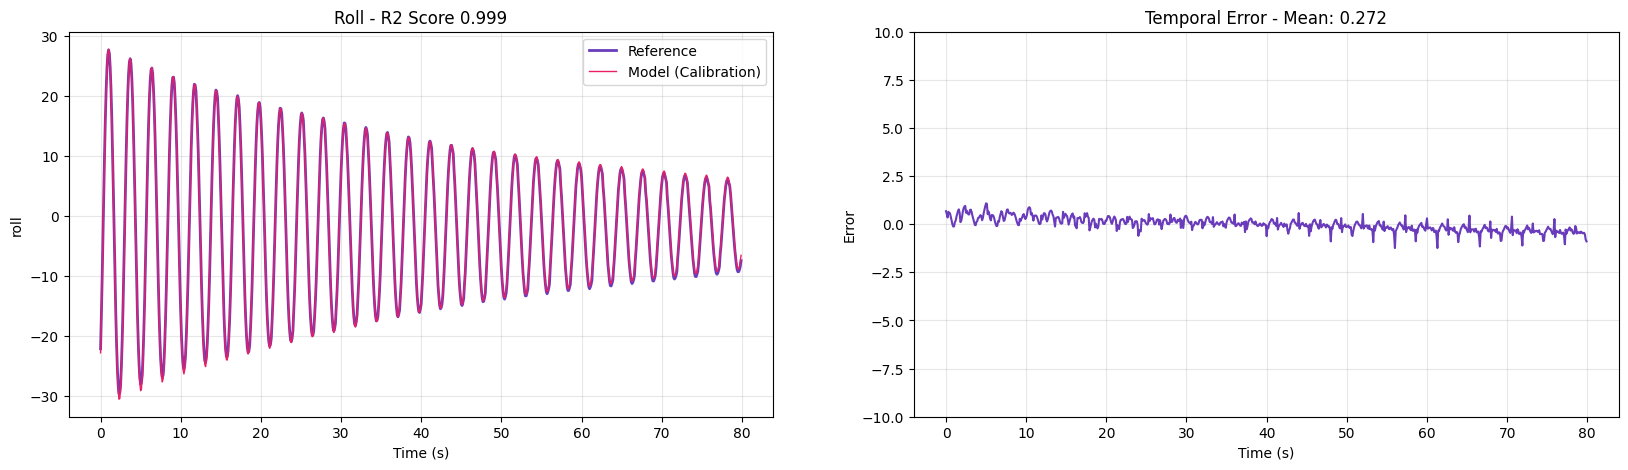

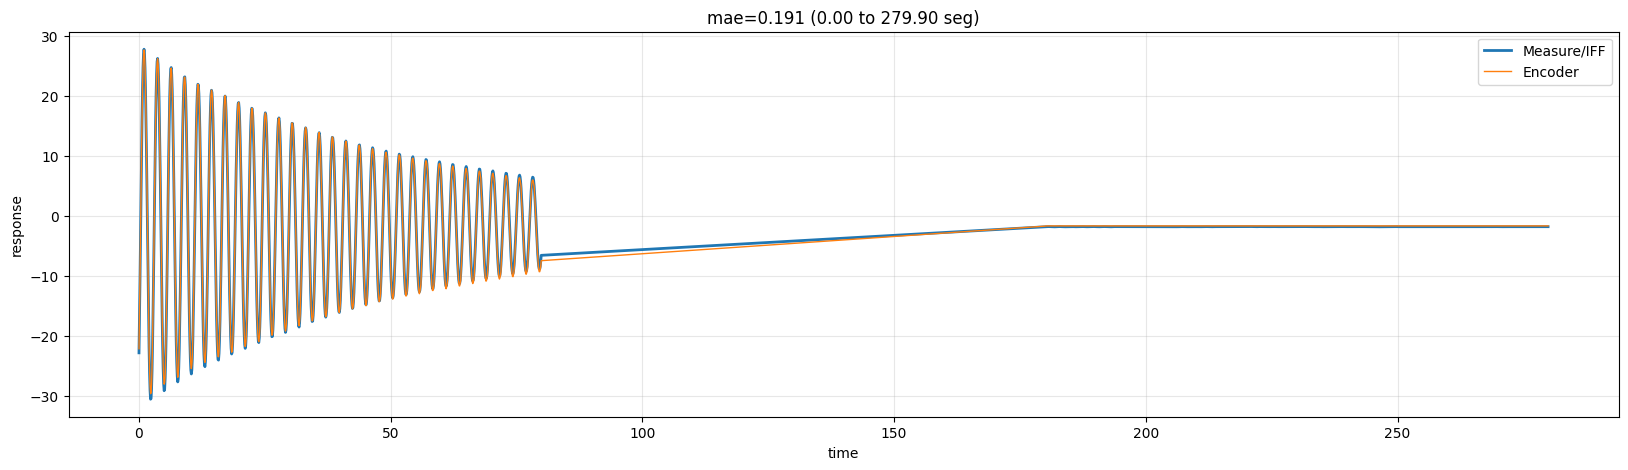

Dinamic Tests (roll)


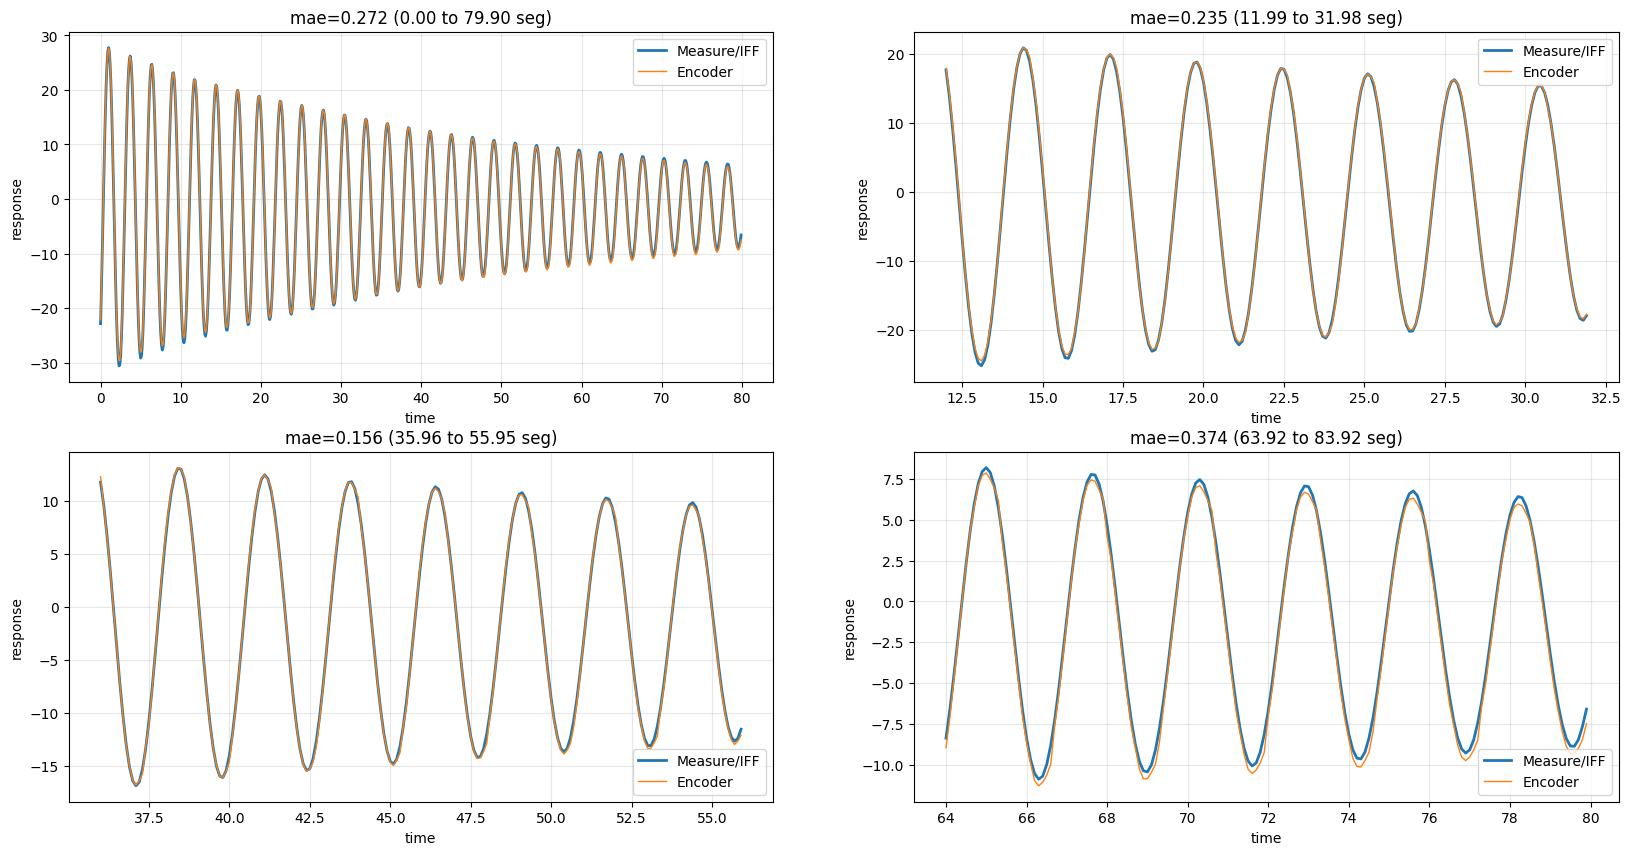

Static Tests (roll)


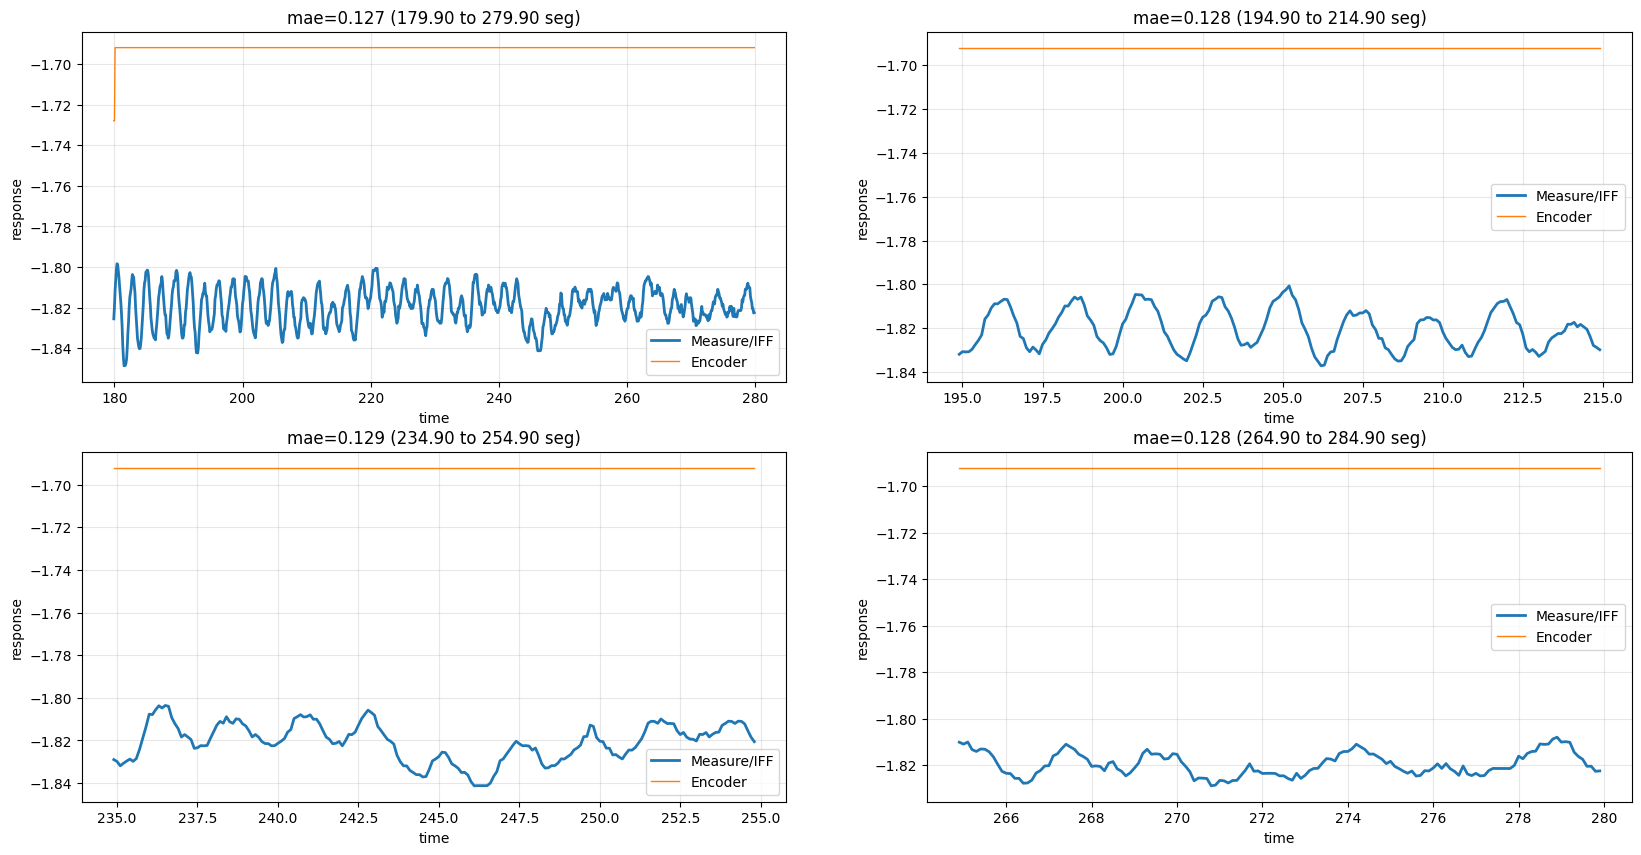

------------------------------------------------------------------------------------- WX -------------------------------------------------------------------------------------


,r2,mae,rmse,precision,rms_stat,rms_dyn,rms_scale_factor,std_stat,time_drift
0,0.999691,0.405819,0.482968,0.03961,0.020089,0.482968,0.003615,0.22216,-0.002784


------------------------------------------------------------------------------------- AZ -------------------------------------------------------------------------------------


,r2,mae,rmse,precision,rms_stat,rms_dyn,rms_scale_factor,std_stat,time_drift
0,0.995908,0.006098,0.015763,0.003598,0.001819,0.015763,0.004274,0.019585,-0.001601


In [13]:
history = {}

for label, variables in groups.items():
    model = LinearFit(df_dynamic, variables, fuse=False)
    model.update()
    model.display()
    
    for idx, var in enumerate(variables):
        if var not in ORIENT_VARS:
            continue

        if var not in calib_axis:
            continue
        
        df_dynamic['model_' + var] = df_dynamic[[f'target_{v}' for v in variables]].values @ model.M[idx] + model.B[idx]
        df_static['model_'  + var] = df_static[[f'target_{v}'  for v in variables]].values @ model.M[idx] + model.B[idx]

        print('-'*85, var.upper(), '-'*85)
        cal = CalibrationAnalysis(model, df_dynamic, df_static, var)
        cal.update()
        cal.display()

        model.metrics[var] = cal.metrics
        exporter = ResultExporter('Certificate', var, model)
        exporter.export()
        history[var] = cal.metrics

        if var != target_axis:
            continue
    
        model.plot(idx)
        plt.show()

        plt.figure(figsize=(20, 5))
        df_united = pd.concat([df_dynamic, df_static], axis=0).sort_values('time')
        plotCurves(df_united, f'model_{var}', f'ref_{var}', limits=(0, 1)) 
        plt.show()

        # ----------------------------- GRÁFICOS DE ZOOM ----------------------------- 
        print(f'Dinamic Tests ({var})')
        spacing = spacing_seconds/(df_dynamic.time.max() - df_dynamic.time.min())
        plt.figure(figsize=(20, 10))
        plt.subplot(2, 2, 1)
        plotCurves(df_dynamic, f'model_{var}', f'ref_{var}', limits=(0, 1))

        plt.subplot(2, 2, 2)
        plotCurves(df_dynamic, f'model_{var}', f'ref_{var}', limits=(0.15, 0.15+spacing))

        plt.subplot(2, 2, 3)
        plotCurves(df_dynamic, f'model_{var}', f'ref_{var}', limits=(0.45, 0.45+spacing))

        plt.subplot(2, 2, 4)
        plotCurves(df_dynamic, f'model_{var}', f'ref_{var}', limits=(0.8, 0.8+spacing))
        plt.show()

        print(f'Static Tests ({var})')
        spacing = spacing_seconds/(df_static.time.max() - df_static.time.min())
        plt.figure(figsize=(20, 10))
        plt.subplot(2, 2, 1)
        plotCurves(df_static, f'model_{var}', f'ref_{var}', limits=(0, 1), norm=False)

        plt.subplot(2, 2, 2)
        plotCurves(df_static, f'model_{var}', f'ref_{var}', limits=(0.15, 0.15+spacing), norm=False)

        plt.subplot(2, 2, 3)
        plotCurves(df_static, f'model_{var}', f'ref_{var}', limits=(0.55, 0.55+spacing), norm=False)

        plt.subplot(2, 2, 4)
        plotCurves(df_static, f'model_{var}', f'ref_{var}', limits=(0.85, 0.85+spacing), norm=False)
        plt.show()

# INFORMAÇÕES GERAIS

In [14]:
pd.DataFrame(history).T.drop(columns=['correctionMatrixRow'])

,r2,mae,rmse,precision,rms_stat,rms_dyn,rms_scale_factor,std_stat,time_drift
roll,0.999184,0.271624,0.34518,0.018158,0.12758,0.34518,0.006023,0.008966,-0.036307
wx,0.999691,0.405819,0.482968,0.03961,0.020089,0.482968,0.003615,0.22216,-0.002784
az,0.995908,0.006098,0.015763,0.003598,0.001819,0.015763,0.004274,0.019585,-0.001601


In [ ]:
# Generate calibration command for firmware
import json as _json

_euler_vars = groups.get('Euler Angles', ['pitch', 'roll', 'yaw'])
_calibration = {}

_model = LinearFit(df_dynamic, _euler_vars, fuse=False)
_model.update()

for _i, _var in enumerate(_euler_vars):
    if _var not in ['pitch', 'roll']:
        continue
    _a = float(_model.M[_i, _i])
    _b = float(_model.B[_i])
    _r2 = _model.metrics[_var]['r2']
    if _r2 < 0.9:
        continue
    _calibration[_var] = {'a': round(_a, 8), 'b': round(_b, 8)}

if _calibration:
    _cmd = f'$calibrate:{_json.dumps(_calibration)}!'
    print('Calibration Command:')
    print(_cmd)
else:
    print('No valid calibration coefficients found')
